## 1. What this notebook computes

In the diagonal frame the field equation of dirac16complex (and of dirac16complex00)
in the author's metric contains the term $3H\gamma^{(8)}\Psi$. This notebook shows,
exactly, that a change of the field VARIABLES removes it, and then studies the
hidden direction $x_8$ near its two ends: the tip $z \to 0$ and the patch end
$z = \pi/2$. It

- takes the spin connection of the diagonal frame from the Revision record and
  verifies it (the gammas are covariantly constant), and recomputes
  $\gamma^\mu\Omega_\mu = 3H\gamma^{(8)}$;
- proves that for $\Psi = \sin^{-1/2}z\,\chi$ the field equation becomes
  $\gamma^\mu\partial_\mu\chi = (m + U')\chi$ with no spin-connection term, for
  sixteen arbitrary component functions, and that the quadratic potential turns
  into the coupling $\lambda S[\chi]/\sin z$;
- verifies the exact family of solutions $\Psi = \sin^\alpha z\,e^{Mx_4}\chi_0$ with
  $k^2 = 9H^2(2\alpha + 1)^2 - m^2$, and finds which members grow ($k^2 > 0$) and
  which have a finite norm at the tip ($\alpha > -\frac12$);
- verifies the growing $x_8$-independent modes of the good sector ($m < 3H$) and
  their finite norm;
- proves that the norm in the hidden direction changes only through a boundary
  term at the patch end $z = \pi/2$, and shows a growing mode whose norm grows
  exactly as fast as this boundary term feeds it.

Every exact statement reproduces a check of a Revision record or is labelled as
this notebook's own exact computation. Five teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 08d (The rescaling that removes the term, and the growing modes at the patch
end) is the file `Revision/textbook/notebooks/08d_rescaling_modes.ipynb` of the
repository Dirac_claude. It takes the spin connection of the diagonal frame from the
Revision record and verifies it, proves exactly that the rescaling Psi = sin(z)^(-1/2)
chi removes the term 3 H gamma^(x8) from the field equation (for 16 arbitrary component
functions) and turns the quadratic potential into the coupling lambda S/sin z, verifies
the exact family of solutions sin(z)^alpha exp(M x4) chi0, finds which of them grow and
which have a finite norm, verifies the growing x8-independent modes of the good sector,
proves that the norm of the hidden direction changes only through a boundary term at the
patch end z = pi/2, and draws five teaching plots. It needs a computer with Windows 11,
macOS or Linux, an internet connection for the installation, the program Git, and Python
3.12 or newer (the notebooks were built with Python 3.14.5) with these packages at
exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 08d_rescaling_modes.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 50 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 08d_rescaling_modes.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
08d_rescaling_modes.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/08d.captions.json`
- `Revision/textbook/figures/08d_1_rescaling_factors.png`
- `Revision/textbook/figures/08d_2_family_k_squared.png`
- `Revision/textbook/figures/08d_3_growing_finite_norm.png`
- `Revision/textbook/figures/08d_4_patch_end_modes.png`
- `Revision/textbook/figures/08d_5_norm_and_flux.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 08d_5_norm_and_flux.png exists
    ALL 23 CHECKS PASSED (notebook 08d)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/08d_rescaling_modes.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- A cell of section 6 or 7 runs for more than a minute.: sympy simplifies the field
  equation for sixteen arbitrary functions there; on a slow computer this can take a few
  minutes. Wait until the star in the brackets to the left of the cell turns into a
  number.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 08d (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 08d (The rescaling that removes the term, and the growing modes at the patch
# end) is the file Revision/textbook/notebooks/08d_rescaling_modes.ipynb of the
# repository Dirac_claude. It takes the spin connection of the diagonal frame from the
# Revision record and verifies it, proves exactly that the rescaling Psi = sin(z)^(-1/2)
# chi removes the term 3 H gamma^(x8) from the field equation (for 16 arbitrary component
# functions) and turns the quadratic potential into the coupling lambda S/sin z, verifies
# the exact family of solutions sin(z)^alpha exp(M x4) chi0, finds which of them grow and
# which have a finite norm, verifies the growing x8-independent modes of the good sector,
# proves that the norm of the hidden direction changes only through a boundary term at
# the patch end z = pi/2, and draws five teaching plots. It needs a computer with Windows
# 11, macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 08d_rescaling_modes.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 50
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 08d_rescaling_modes.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 08d_rescaling_modes.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/08d.captions.json
# - Revision/textbook/figures/08d_1_rescaling_factors.png
# - Revision/textbook/figures/08d_2_family_k_squared.png
# - Revision/textbook/figures/08d_3_growing_finite_norm.png
# - Revision/textbook/figures/08d_4_patch_end_modes.png
# - Revision/textbook/figures/08d_5_norm_and_flux.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 08d_5_norm_and_flux.png exists
#     ALL 23 CHECKS PASSED (notebook 08d)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/08d_rescaling_modes.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - A cell of section 6 or 7 runs for more than a minute.: sympy simplifies the field
#   equation for sixteen arbitrary functions there; on a slow computer this can take a
#   few minutes. Wait until the star in the brackets to the left of the cell turns into a
#   number.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "08d"  # this notebook: chapter 08, example d


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 08d complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** (the author's names): $x_1, x_2, x_3$ ordinary space (inflating);
  $x_4$ the time; $x_5, x_6, x_7$ the three extra times (time-like, DEFLATING);
  $x_8$ the hidden direction, $z = 6Hx_8$ between $0$ (the *tip*) and $\pi/2$ (the
  *patch end*, at $x_8 = \pi/(12H)$).
- **Diagonal frame**, scale factors $f_a$: $f_{1,2,3} = e^{a_4}\sin^{1/6}z$,
  $f_4 = 1$, $f_{5,6,7} = e^{-a_4}\sin^{1/6}z$, $f_8 = \cot z$; $\gamma^\mu =
  \gamma^{(\mu)}/f_\mu$.
- **Spin connection** $\Omega_\mu$ and **covariant derivative** $D_\mu\Psi =
  \partial_\mu\Psi + \Omega_\mu\Psi$; the gammas are *covariantly constant*:
  $\partial_\mu\gamma^\nu + \sum_\lambda\Gamma^\nu{}_{\mu\lambda}\gamma^\lambda +
  \Omega_\mu\gamma^\nu - \gamma^\nu\Omega_\mu = 0$ ($\Gamma$: Christoffel symbols).
  This property fixes $\Omega_\mu$ and is used to verify it.
- **Rescaling** (a change of field variables): $\Psi = w\,\chi$ with the function
  $w = \sin^{-1/2}z$.
- **Bilinear** $S = \bar\Psi\Psi = \Psi^\dagger C\Psi$ and the quadratic potential
  $U = \frac{\lambda}{2}S^2$, $U' = \lambda S$.
- **Norm** of a field in the hidden direction: $\int \cos z\,\Psi^\dagger\Psi\,dx_8$
  ($\cos z = \sqrt{|g|}$ is the volume factor). It is *finite* when the integral
  does not diverge at the ends.
- **Hidden coordinate** $y = \ln(\sin z)/(6H)$, $dy = \cot z\,dx_8$; $y = 0$ at the
  patch end and $y \to -\infty$ at the tip.
- **Good sector**: fields that do not depend on the extra times $x_5, x_6, x_7$.
- **Mode operator** $h$: the field equation written as $i\,\partial_4\Psi = h\Psi$;
  for fields that depend only on $x_4$ and $x_8$ (and $U = 0$),
  $h = -im\gamma^{(4)} + i\gamma^{(4)}\gamma^{(8)}(\tan z\,\partial_8 + 3H)$.
- **Hermitian, anti-Hermitian**: $M^\dagger = M$ or $M^\dagger = -M$
  ($M^\dagger$: the conjugate transpose).
- **Boundary term (flux)**: a total derivative $\partial_8(\dots)$ whose integral is
  the difference of its values at the two ends.

## 4. The physical and mathematical situation

For a field that depends only on $x_4$ and $x_8$ the field equation (with $U = 0$)
is $\gamma^{(4)}\partial_4\Psi + \tan z\,\gamma^{(8)}\partial_8\Psi +
3H\gamma^{(8)}\Psi = m\Psi$. The rescaling works because, line by line,

1. $\partial_8\sin^{-1/2}z = -\frac12\sin^{-3/2}z\cos z \cdot 6H$ (chain rule, with
   $dz/dx_8 = 6H$);
2. so $\tan z\,\partial_8\sin^{-1/2}z = -3H\,\sin^{-1/2}z$ (because $\tan z\cos z =
   \sin z$);
3. so $\tan z\,\gamma^{(8)}\partial_8(w\chi) + 3H\gamma^{(8)}w\chi =
   w\tan z\,\gamma^{(8)}\partial_8\chi$: the product rule produces exactly
   $-3H\gamma^{(8)}w\chi$, which cancels the spin-connection term.

The weight moves into the measure: $\cos z\,\Psi^\dagger\Psi\,dx_8 = \cos z\,
\sin^{-1}z\,\chi^\dagger\chi\,dx_8 = \chi^\dagger\chi\,dy$.

Proper lengths along the hidden direction are $\sqrt{g_{88}}\,dx_8 = \cot z\,dx_8 =
dy$. So the *patch end* $z = \pi/2$ ($y = 0$) lies at the finite proper distance
$|y|$ from every point, while the tip $z \to 0$ ($y \to -\infty$) is infinitely far
away. The Revision
record imposes no boundary condition at $z = \pi/2$ (the Kohn-Sham record ASSUMES a
$Z_2$ brane there). Without one, the mode operator is symmetric only up to a
boundary term at $z = \pi/2$, and the good sector contains growing modes: this is
the second way (besides the extra-time waves) in which the initial-value problem
fails to be well posed.

Every symbol is exact ($H > 0$, $m$, $\alpha$, $\lambda$ letters; $a_4(x_4)$ any
function). The plots use $H = 1$.

## 5. The spin connection from the record, verified

The next cell first defines two helpers for the checks that reproduce a Revision
record. `record_says(report, name, ...)` opens the report (a JSON file with a list
of checks, each with a name, a verdict and a detail text) and is true when the
check `name` is there with the verdict pass and its detail text contains every
further piece of text given (for example a value that this notebook computes).
`check_record(condition, title, report, name, ...)` is the helper `check` for such
a result: it passes only if the notebook's own computation (`condition`) is right
AND the record says the same. Then the cell reads the gammas and the formula
record `Omega_components` of
`Revision/theory/field-theory.json` (written in the Wolfram language: `g[xi]` is
$\gamma^{(x_i)}$, `a4'[x4]` is $a_4'$), enters the same formula in sympy, computes
the Christoffel symbols of the author's metric, and checks that the gammas are
covariantly constant for all 64 pairs $(\mu, \nu)$ and that $\gamma^\mu\Omega_\mu =
3H\gamma^{(8)}$. The helper `is_zero` asks sympy to simplify twice (the second time
with its trigonometric simplifier `fu`).

In [2]:
import numpy as np  # numbers and matrices (for the plots)
import sympy as sp  # exact algebra with symbols

REPORTS = {}  # report file -> {check name: (verdict, detail)}, each read once


def record_says(report_file, check_name, *pieces):
    """True when the Revision report records the check check_name with the verdict
    pass and its detail text contains every given piece of text."""
    if report_file not in REPORTS:  # read the report the first time it is needed
        data = json.loads(repository_file(report_file).read_text(encoding="utf-8"))
        REPORTS[report_file] = {entry["name"]: (entry["verdict"].lower(),
                                                entry["detail"])
                                for entry in data["checks"]}
    verdict, detail = REPORTS[report_file][check_name]
    return verdict == "pass" and all(piece in detail for piece in pieces)


def check_record(condition, title, report_file, check_name, *pieces):
    """check() for a result that reproduces the Revision check check_name: it passes
    only if condition is true AND the report records check_name as passed, with
    every piece of text (values computed here) in its detail."""
    on_record = record_says(report_file, check_name, *pieces)
    check(condition and on_record, title,
          record=f"{report_file}, check {check_name}")


THEORY = "Revision/theory/reports/python-field-theory.json"  # the sympy records
SCOPE = "Revision/theory/reports/python-scope.json"
gammas_record = json.loads(
    repository_file("Revision/algebra/gammas.json").read_text(encoding="utf-8"))
G = [sp.Matrix(rows) for rows in gammas_record["gamma"]]  # gamma^(x1) ... (x8)
ETA = gammas_record["eta"]  # [1, 1, 1, -1, -1, -1, -1, 1]
C = sp.Matrix(gammas_record["C"])  # C = gamma^(x8) gamma^(x1) gamma^(x2) gamma^(x3)
B = sp.Matrix(gammas_record["B"]["re"]) + sp.I * sp.Matrix(gammas_record["B"]["im"])
theory = json.loads(
    repository_file("Revision/theory/field-theory.json").read_text(encoding="utf-8"))
formulas = {entry["key"]: entry for entry in theory["formulas"]}
say("record Omega_components: " + formulas["Omega_components"]["wl"])

x = sp.symbols("x1:9", real=True)  # the coordinates; x[3] is x4, x[7] is x8
H = sp.Symbol("H", positive=True)
m = sp.Symbol("m", real=True)
a4 = sp.Function("a4")(x[3])  # any function of the time x4
a4_prime = sp.diff(a4, x[3])
z = 6 * H * x[7]
sixth = sp.sin(z) ** sp.Rational(1, 6)
f = [sp.exp(a4) * sixth] * 3 + [sp.Integer(1)] + [sp.exp(-a4) * sixth] * 3 \
    + [sp.cot(z)]
g = [ETA[a] * f[a] ** 2 for a in range(8)]  # the diagonal metric
gamma_up = [G[mu] / f[mu] for mu in range(8)]  # gamma^mu = gamma^(mu) / f_mu
Omega = [sp.zeros(16, 16) for _ in range(8)]
for i in (0, 1, 2):  # x1, x2, x3 (inflating)
    Omega[i] = sp.exp(a4) * sixth * (a4_prime * G[i] * G[3] + H * G[i] * G[7]) / 2
for t in (4, 5, 6):  # x5, x6, x7 (deflating extra times)
    Omega[t] = -sp.exp(-a4) * sixth * (a4_prime * G[3] * G[t] + H * G[t] * G[7]) / 2


def is_zero(expr):
    """True when sympy shows that expr is exactly zero (two simplifications)."""
    expr = sp.sympify(expr)
    if expr == 0:
        return True
    simpler = sp.simplify(expr)
    return simpler == 0 or sp.simplify(sp.fu(simpler)) == 0


Gam = [[[sp.Integer(0)] * 8 for _ in range(8)] for _ in range(8)]
for lam in range(8):  # Christoffel symbols of the diagonal metric
    for mu in range(8):
        for nu in range(8):
            value = 0
            if lam == nu:
                value += sp.diff(g[lam], x[mu])
            if lam == mu:
                value += sp.diff(g[lam], x[nu])
            if mu == nu:
                value -= sp.diff(g[mu], x[lam])
            if value != 0:
                Gam[lam][mu][nu] = sp.simplify(value / (2 * g[lam]))
constant = all(
    all(is_zero(v) for v in sp.diff(gamma_up[nu], x[mu])
        + sum((Gam[nu][mu][lam] * gamma_up[lam] for lam in range(8)), sp.zeros(16, 16))
        + Omega[mu] * gamma_up[nu] - gamma_up[nu] * Omega[mu])
    for mu in range(8) for nu in range(8))
check_record(constant, "the record's Omega_mu makes every gamma^nu covariantly "
             "constant (64 pairs)", THEORY, "covariant_constancy_D_mu_gamma_nu",
             "= 0 for all 64 (mu, nu)")
gamma_Omega = sum((gamma_up[mu] * Omega[mu] for mu in range(8)), sp.zeros(16, 16))
check_record(all(is_zero(v) for v in gamma_Omega - 3 * H * G[7]),
             "gamma^mu Omega_mu = 3 H gamma^(x8) (diagonal frame)",
             THEORY, "gamma_mu_Omega_mu_equals_3H_gamma_x8",
             "gamma^mu Omega_mu = 3 H gamma^(x8) exactly")

record Omega_components: Omega_xi = (1/2) E^a4[x4] Sin[6 H x8]^(1/6) (a4'[x4] g[xi].g[x4]
    + H g[xi].g[x8]) (i = 1, 2, 3); Omega_xt = -(1/2) E^-a4[x4] Sin[6 H x8]^(1/6)
    (a4'[x4] g[x4].g[xt] + H g[xt].g[x8]) (t = 5, 6, 7); Omega_x4 = Omega_x8 = 0; g[xa] =
    gamma^(xa) (frame gammas of the fixture)
PASS the record's Omega_mu makes every gamma^nu covariantly constant (64 pairs)
     reproduces Revision/theory/reports/python-field-theory.json, check
    covariant_constancy_D_mu_gamma_nu
PASS gamma^mu Omega_mu = 3 H gamma^(x8) (diagonal frame)
     reproduces Revision/theory/reports/python-field-theory.json, check
    gamma_mu_Omega_mu_equals_3H_gamma_x8


## 6. The rescaling removes the term

The next cell checks the one-line identity $\tan z\,\partial_8\sin^{-1/2}z =
-3H\sin^{-1/2}z$, and then the full statement on sixteen ARBITRARY component
functions $\chi_A(x_1, \dots, x_8)$ (sympy `Function` objects, about which nothing
is assumed): $\gamma^\mu D_\mu(w\chi) - w\,\gamma^\mu\partial_\mu\chi = 0$ for all 16
components. Then it checks the potential: $S[w\chi] = w^2S[\chi] = S[\chi]/\sin z$
($w$ is real), so $\lambda S[\Psi]\Psi = w\,\frac{\lambda S[\chi]}{\sin z}\chi$, and
the measure: $\cos z\,w^2 = \cot z = dy/dx_8$.

In [3]:
w = sp.sin(z) ** sp.Rational(-1, 2)  # the rescaling factor sin(z)^(-1/2)
check_record(is_zero(sp.tan(z) * sp.diff(w, x[7]) + 3 * H * w),
             "tan z d8 sin(z)^(-1/2) = -3 H sin(z)^(-1/2)", SCOPE,
             "rescaling_removes_the_connection_term",
             "(tan z (-3 H sin^(-1/2) z) + 3 H sin^(-1/2) z) gamma^(x8) chi = 0")
chi = sp.Matrix([sp.Function(f"chi{A}")(*x) for A in range(1, 17)])  # arbitrary
Psi = w * chi
D_Psi = sum((gamma_up[mu] * (sp.diff(Psi, x[mu]) + Omega[mu] * Psi)
             for mu in range(8)), sp.zeros(16, 1))  # gamma^mu D_mu Psi
D_chi = sum((gamma_up[mu] * sp.diff(chi, x[mu]) for mu in range(8)),
            sp.zeros(16, 1))  # gamma^mu d_mu chi (no connection)
check_record(all(is_zero(v) for v in D_Psi - w * D_chi),
             "gamma^mu D_mu (w chi) = w gamma^mu d_mu chi for 16 arbitrary functions",
             SCOPE, "rescaling_removes_the_connection_term",
             "the field equation has no spin-connection term: gamma^mu d_mu chi = "
             "(m + U'(S)) chi")
lam, S_chi = sp.symbols("lambda S_chi", real=True)  # S_chi stands for S[chi]
S_Psi = w**2 * S_chi  # S[w chi] = (w chi)^dagger C (w chi) = w^2 S[chi]
check_record(is_zero(lam * S_Psi - lam * S_chi / sp.sin(z)),
             "U = (lambda/2) S^2: lambda S[Psi] = lambda S[chi]/sin z (the new "
             "coupling)", SCOPE, "rescaled_equation_quadratic_potential",
             "gamma^mu d_mu chi = (m + lambda S[chi]/sin z) chi")
y_of_x8 = sp.log(sp.sin(z)) / (6 * H)
check(is_zero(sp.cos(z) * w**2 - sp.cot(z)) and
      is_zero(sp.diff(y_of_x8, x[7]) - sp.cot(z)),
      "cos z w^2 = cot z = dy/dx8: the norm of Psi is the y-norm of chi")

PASS tan z d8 sin(z)^(-1/2) = -3 H sin(z)^(-1/2)
     reproduces Revision/theory/reports/python-scope.json, check
    rescaling_removes_the_connection_term
PASS gamma^mu D_mu (w chi) = w gamma^mu d_mu chi for 16 arbitrary functions
     reproduces Revision/theory/reports/python-scope.json, check
    rescaling_removes_the_connection_term
PASS U = (lambda/2) S^2: lambda S[Psi] = lambda S[chi]/sin z (the new coupling)
     reproduces Revision/theory/reports/python-scope.json, check
    rescaled_equation_quadratic_potential
PASS cos z w^2 = cot z = dy/dx8: the norm of Psi is the y-norm of chi


The next cell draws the rescaling factor $w = \sin^{-1/2}z$, the new coupling factor
$1/\sin z$ of the potential, and the hidden coordinate $y = \ln(\sin z)/(6H)$, for
$H = 1$. It reads $H$ and the tip cutoff $L$ of the Kohn-Sham record (that record
cuts the hidden direction at $y = -L$) and computes where the cutoff lies in $z$:
$y = -L$ means $\ln(\sin z) = -6HL$, so $\sin z = e^{-6HL}$ and
$z_{\rm cut} = \arcsin(e^{-6HL})$. This number is tiny, so the right panel uses a
logarithmic $z$ axis: on it $y$ is almost a straight line, because $\sin z \approx
z$ for small $z$ and then $y \approx \ln(z)/(6H)$.

RESULT H and the tip cutoff L of the Kohn-Sham record = 1.0, 3.0
RESULT z at the tip cutoff, arcsin(e^(-6 H L)) = 1.522998e-08
PASS the record has H = 1, and y(z_cut) = -L
     reproduces Revision/kohn_sham/results/parameters.json, physics.H,
    physics.L_tipCutoff


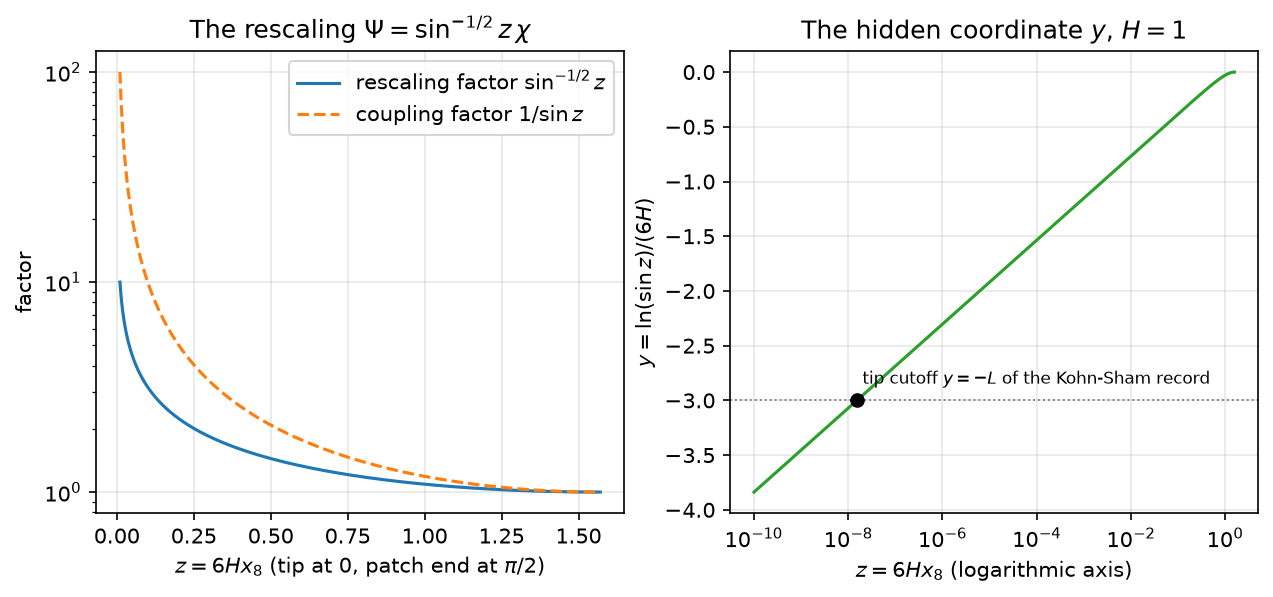

Figure 08d.1 saved as Revision/textbook/figures/08d_1_rescaling_factors.png


In [4]:
parameters = json.loads(repository_file(
    "Revision/kohn_sham/results/parameters.json").read_text(encoding="utf-8"))
H_record = parameters["physics"]["H"]  # the author's constant H of the record
L_tip = parameters["physics"]["L_tipCutoff"]  # the record cuts the tip at y = -L
z_cut = np.arcsin(np.exp(-6 * H_record * L_tip))  # the z at which y = -L
report("H and the tip cutoff L of the Kohn-Sham record", f"{H_record}, {L_tip}")
report("z at the tip cutoff, arcsin(e^(-6 H L))", f"{z_cut:.6e}")
check(H_record == 1.0 and abs(np.log(np.sin(z_cut)) / (6 * H_record) + L_tip) < 1e-12,
      "the record has H = 1, and y(z_cut) = -L",
      record="Revision/kohn_sham/results/parameters.json, physics.H, "
             "physics.L_tipCutoff")
zs = np.linspace(0.01, np.pi / 2, 400)
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
left.plot(zs, np.sin(zs) ** -0.5, label="rescaling factor $\\sin^{-1/2}z$")
left.plot(zs, 1 / np.sin(zs), "--", label="coupling factor $1/\\sin z$")
left.set_yscale("log")
left.set_xlabel("$z = 6Hx_8$ (tip at 0, patch end at $\\pi/2$)")
left.set_ylabel("factor")
left.set_title("The rescaling $\\Psi = \\sin^{-1/2}z\\,\\chi$")
left.legend()
mantissa, exponent = f"{z_cut:.1e}".split("e")  # "1.5e-08" -> "1.5" and "-08"
exponent = int(exponent)  # -8, for the caption
z_log = np.logspace(-10.0, np.log10(np.pi / 2), 400)  # 10^-10 ... pi/2, log spaced
right.semilogx(z_log, np.log(np.sin(z_log)) / (6 * H_record), color="tab:green")
right.axhline(-L_tip, color="gray", linestyle=":", linewidth=0.9)
right.plot([z_cut], [-L_tip], "o", color="black")  # where y reaches the cutoff
right.text(2e-8, -L_tip + 0.15, "tip cutoff $y = -L$ of the Kohn-Sham record",
           fontsize=8)
right.set_xlabel("$z = 6Hx_8$ (logarithmic axis)")
right.set_ylabel("$y = \\ln(\\sin z)/(6H)$")
right.set_title("The hidden coordinate $y$, $H = 1$")
save_figure(fig, "rescaling_factors",
            "Left, on a logarithmic axis, against $z = 6Hx_8$ from the tip (near 0) "
            "to the patch end ($\\pi/2$): the rescaling factor $\\sin^{-1/2}z$ "
            "(solid) of $\\Psi = \\sin^{-1/2}z\\,\\chi$, which removes the term "
            "$3H\\gamma^{(8)}$, and the factor $1/\\sin z$ (dashed) of the new "
            "coupling $\\lambda S_\\chi/\\sin z$; both equal 1 at the patch end and "
            "diverge at the tip. Right: the hidden coordinate $y = \\ln(\\sin z)/"
            "(6H)$ for $H = 1$, in which the norm of $\\Psi$ is $\\int\\chi^\\dagger"
            "\\chi\\,dy$, against $z$ on a logarithmic axis; $y = 0$ at the patch "
            "end and $y \\to -\\infty$ at the tip. Dotted: the cutoff "
            f"$y = -L = {-L_tip:g}$ of the Kohn-Sham record, reached only at "
            f"$z = \\arcsin(e^{{{-6 * H_record * L_tip:g}}}) \\approx {mantissa} "
            f"\\times 10^{{{exponent}}}$ (black dot): almost the whole range of $y$ "
            "lies in a tiny neighbourhood of the tip.")

## 7. An exact family of solutions

For $U = 0$ and a field that depends only on $x_4$ and $x_8$ the record gives the
family $\Psi = \sin^\alpha z\,\big(\cosh(kx_4) + \frac{\sinh(kx_4)}{k}M\big)\chi_0$
with a constant column $\chi_0$, $M = -m\gamma^{(4)} + c\,\gamma^{(4)}\gamma^{(8)}$,
$c = 3H(2\alpha + 1)$ and $k^2 = c^2 - m^2$. The bracket is $e^{Mx_4}$, because
$M^2 = k^2 I_{16}$. The next cell checks $M^2 = (c^2 - m^2)I_{16}$ and
$M^TC + CM = 0$ (so $S$ does not change in time), and then that $\Psi$ solves the
full field equation $\gamma^\mu D_\mu\Psi = m\Psi$ (all eight directions, with the
spin connection of section 5) for symbolic $\alpha$, $m$, $H$ and every $a_4$.
For $\alpha = -\frac12$: $c = 0$, $M = -m\gamma^{(4)}$ contains no $H$, and
$k^2 = -m^2$ (oscillation with frequency $m$): this is the rescaling of section 6
at work.

In [5]:
alpha = sp.Symbol("alpha", real=True)
c = 3 * H * (2 * alpha + 1)
k = sp.sqrt(c**2 - m**2)  # k^2 = 9 H^2 (2 alpha + 1)^2 - m^2
M = -m * G[3] + c * G[3] * G[7]
check_record((M * M - (c**2 - m**2) * sp.eye(16)).applyfunc(sp.expand)
             == sp.zeros(16, 16)
             and (M.T * C + C * M).applyfunc(sp.expand) == sp.zeros(16, 16),
             "M^2 = (9 H^2 (2 alpha + 1)^2 - m^2) I16 and M^T C + C M = 0",
             THEORY, "exact_solution_family_x4_x8",
             "M = -m gamma^(x4) + 3 H (2 alpha + 1) gamma^(x4) gamma^(x8)",
             "k^2 = 9 H^2 (2 alpha + 1)^2 - m^2", "(M^2 = k^2 I16, M^T C + C M = 0")
chi0 = sp.Matrix(sp.symbols("q1:17"))  # 16 arbitrary constants
family = sp.sin(z) ** alpha * (sp.cosh(k * x[3]) * chi0
                               + sp.sinh(k * x[3]) / k * (M * chi0))
residual = sum((gamma_up[mu] * (sp.diff(family, x[mu]) + Omega[mu] * family)
                for mu in range(8)), sp.zeros(16, 1)) - m * family
check_record(all(is_zero(v) for v in residual),
             "Psi = sin(z)^alpha (cosh(k x4) + sinh(k x4)/k M) chi0 solves the field "
             "equation", THEORY, "exact_solution_family_x4_x8",
             "solves gamma^mu D_mu Psi = m Psi exactly for every a4(x4) and every "
             "alpha")
M_half = M.subs(alpha, -sp.Rational(1, 2))
check_record(not M_half.has(H)
             and sp.expand(k.subs(alpha, -sp.Rational(1, 2)) ** 2) == -m**2,
             "alpha = -1/2: M = -m gamma^(x4) has no H and k^2 = -m^2 (oscillation)",
             SCOPE, "rescaled_equation_quadratic_potential",
             "= -m gamma^(x4) and k^2 = -m^2 (no H)")

PASS M^2 = (9 H^2 (2 alpha + 1)^2 - m^2) I16 and M^T C + C M = 0
     reproduces Revision/theory/reports/python-field-theory.json, check
    exact_solution_family_x4_x8
PASS Psi = sin(z)^alpha (cosh(k x4) + sinh(k x4)/k M) chi0 solves the field equation
     reproduces Revision/theory/reports/python-field-theory.json, check
    exact_solution_family_x4_x8
PASS alpha = -1/2: M = -m gamma^(x4) has no H and k^2 = -m^2 (oscillation)
     reproduces Revision/theory/reports/python-scope.json, check
    rescaled_equation_quadratic_potential


## 8. Which members grow, and which have a finite norm

A member GROWS when $k^2 > 0$, that is when $3H|2\alpha + 1| > m$. Its norm in the
hidden direction is $\int_0^{\pi/(12H)}\cos z\,\sin^{2\alpha}z\,dx_8$ times a
function of $x_4$; with $s = \sin z$, $ds = 6H\cos z\,dx_8$, this is
$\frac{1}{6H}\int_0^1 s^{2\alpha}ds$, which is $\frac{1}{6H(2\alpha + 1)}$ for
$\alpha > -\frac12$ and infinite for $\alpha \le -\frac12$ (at $\alpha = -\frac12$
the integral of $1/s$ diverges like $\ln$ at the tip). So the H-free member
$\alpha = -\frac12$ has an infinite norm, and the growing members with a finite norm
are those with $2\alpha + 1 > m/(3H)$. For EVERY mass $m > 0$ there are such
members: $\alpha = m/(3H)$ gives $k^2 = (2m + 3H)^2 - m^2 = 3(m + H)(m + 3H) > 0$.
The Revision record states the $x_8$-independent case $\alpha = 0$, which grows when
$m < 3H$; the statement for every mass is this notebook's own exact consequence of
the record's family. The next cell checks the integrals and this example, and draws
$k^2$ against $\alpha$ for three masses.

PASS int_0^1 s^(2 alpha) ds = 1/(2 alpha + 1) for 2 alpha + 1 > 0; diverges at -1/2
k^2 at alpha = m/(3H): 3*(H + m)*(3*H + m)
PASS alpha = m/(3H) > -1/2 gives k^2 = 3 (m + H)(m + 3H) > 0 for every m > 0


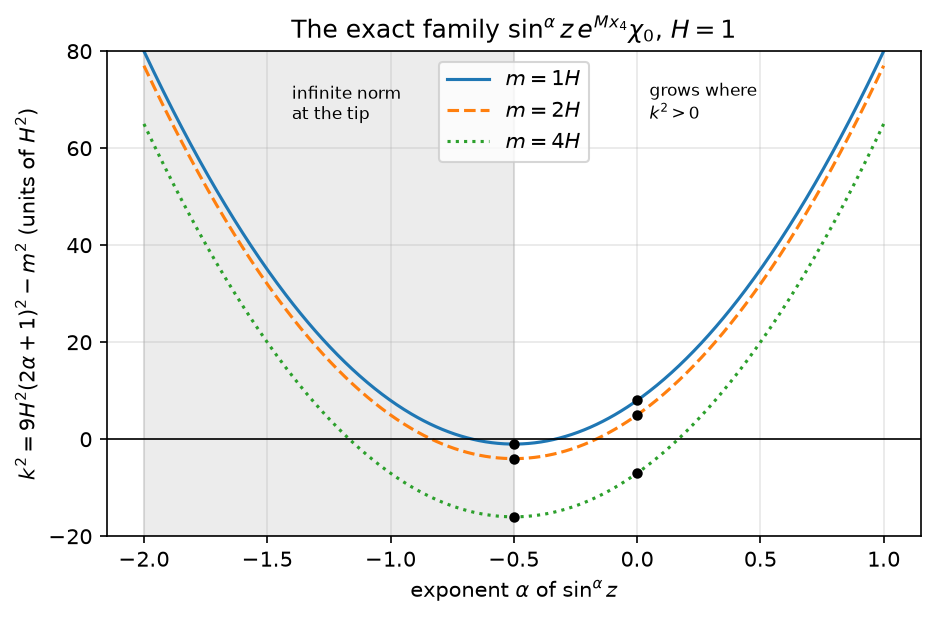

Figure 08d.2 saved as Revision/textbook/figures/08d_2_family_k_squared.png


In [6]:
s, p, eps = sp.symbols("s p epsilon", positive=True)
check(sp.integrate(s ** (p - 1), (s, 0, 1)) == 1 / p and
      sp.limit(sp.integrate(1 / s, (s, eps, 1)), eps, 0, "+") == sp.oo,
      "int_0^1 s^(2 alpha) ds = 1/(2 alpha + 1) for 2 alpha + 1 > 0; diverges at -1/2")
k2_every_mass = sp.factor(sp.expand((c**2 - m**2).subs(alpha, m / (3 * H))))
say(f"k^2 at alpha = m/(3H): {k2_every_mass}")
check(sp.expand(k2_every_mass - 3 * (m + H) * (m + 3 * H)) == 0,
      "alpha = m/(3H) > -1/2 gives k^2 = 3 (m + H)(m + 3H) > 0 for every m > 0")

alphas = np.linspace(-2.0, 1.0, 601)
fig, ax = plt.subplots()
for mass, style in ((1.0, "-"), (2.0, "--"), (4.0, ":")):
    ax.plot(alphas, 9 * (2 * alphas + 1) ** 2 - mass**2, style, label=f"$m = {mass:g}H$")
    ax.plot([-0.5, 0.0], [-mass**2, 9 - mass**2], "o", color="black", markersize=4)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.axvspan(-2.0, -0.5, color="gray", alpha=0.15)
ax.text(-1.4, 66, "infinite norm\nat the tip", fontsize=8)
ax.text(0.05, 66, "grows where\n$k^2 > 0$", fontsize=8)
ax.set_ylim(-20.0, 80.0)
ax.set_xlabel("exponent $\\alpha$ of $\\sin^{\\alpha}z$")
ax.set_ylabel("$k^2 = 9H^2(2\\alpha + 1)^2 - m^2$ (units of $H^2$)")
ax.set_title("The exact family $\\sin^\\alpha z\\,e^{Mx_4}\\chi_0$, $H = 1$")
ax.legend(loc="upper center");
save_figure(fig, "family_k_squared",
            "The number $k^2 = 9H^2(2\\alpha + 1)^2 - m^2$ of the exact family of "
            "solutions $\\sin^\\alpha z\\,e^{Mx_4}\\chi_0$ against the exponent "
            "$\\alpha$, for the masses $m = H, 2H, 4H$ ($H = 1$; vertical axis in "
            "units of $H^2$). Where $k^2 > 0$ the member grows like $e^{kx_4}$, "
            "where $k^2 < 0$ it oscillates. The black dots mark $\\alpha = -1/2$ "
            "($k^2 = -m^2$, no $H$: the rescaled field) and $\\alpha = 0$ ($k^2 = "
            "9H^2 - m^2$, the $x_8$-independent modes). In the gray region "
            "$\\alpha \\le -1/2$ the norm diverges at the tip; to the right of it "
            "every parabola becomes positive, so for every mass some member with a "
            "finite norm grows.")

The next cell draws the same information in the plane of $\alpha$ and the mass
$m/H$: the region of growing members with a finite norm is $\alpha > -\frac12$ and
$2\alpha + 1 > m/(3H)$. The horizontal line $\alpha = 0$ crosses it exactly for
$m < 3H$, the case stated in the Revision record.

RESULT fraction of the drawn (m, alpha) rectangle that grows with finite norm = 0.5996
PASS for every drawn mass some alpha gives a growing finite-norm member


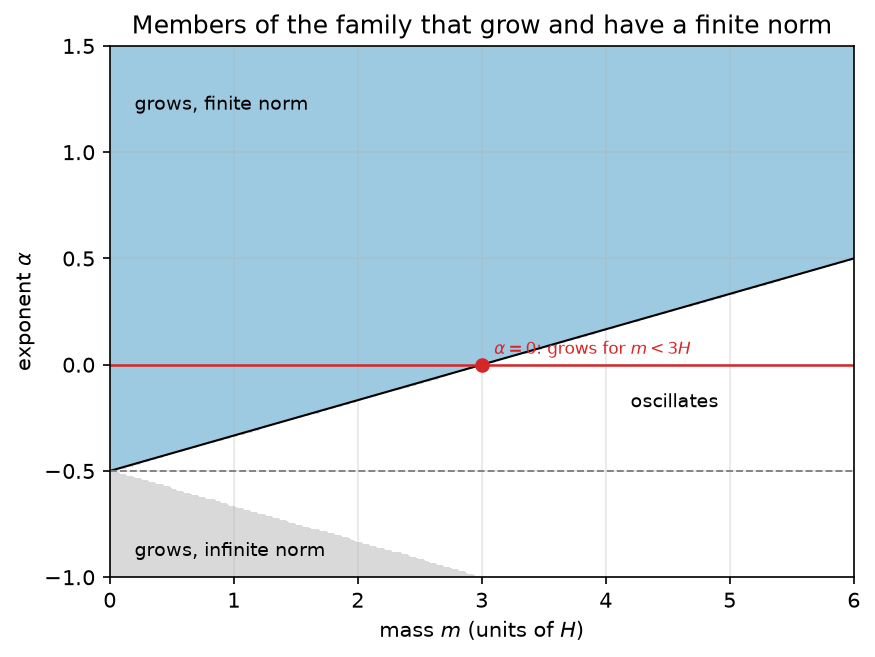

Figure 08d.3 saved as Revision/textbook/figures/08d_3_growing_finite_norm.png


In [7]:
masses = np.linspace(0.0, 6.0, 301)
A_grid, M_grid = np.meshgrid(np.linspace(-1.0, 1.5, 251), masses)
grows = 9 * (2 * A_grid + 1) ** 2 - M_grid**2 > 0
finite = A_grid > -0.5
region = np.where(grows & finite, 2, np.where(grows, 1, 0))  # 2, 1 or 0
fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.contourf(M_grid, A_grid, region, levels=[-0.5, 0.5, 1.5, 2.5],
            colors=["white", "#d9d9d9", "#9ecae1"])
ax.plot(masses, (masses / 3 - 1) / 2, color="black", linewidth=1.0)
ax.axhline(-0.5, color="gray", linestyle="--", linewidth=0.9)
ax.axhline(0.0, color="tab:red", linewidth=1.2)
ax.plot([3.0], [0.0], "o", color="tab:red")
ax.text(0.2, 1.2, "grows, finite norm", fontsize=9)
ax.text(4.2, -0.2, "oscillates", fontsize=9)
ax.text(0.2, -0.9, "grows, infinite norm", fontsize=9)
ax.text(3.1, 0.05, "$\\alpha = 0$: grows for $m < 3H$", fontsize=8, color="tab:red")
ax.set_xlabel("mass $m$ (units of $H$)")
ax.set_ylabel("exponent $\\alpha$")
ax.set_title("Members of the family that grow and have a finite norm")
fraction = float(np.mean(grows & finite))
report("fraction of the drawn (m, alpha) rectangle that grows with finite norm",
       f"{fraction:.4f}")
check(all(np.any(grows[i] & finite[i]) for i in range(len(masses))),
      "for every drawn mass some alpha gives a growing finite-norm member")
save_figure(fig, "growing_finite_norm",
            "The plane of the mass $m$ (horizontal, units of $H$) and the exponent "
            "$\\alpha$ (vertical) of the exact family $\\sin^\\alpha z\\,"
            "e^{Mx_4}\\chi_0$. Blue: the member grows ($k^2 > 0$) and has a finite "
            "norm at the tip ($\\alpha > -1/2$, above the dashed line). Gray: it "
            "grows but its norm diverges. White: it oscillates. The black line is "
            "$2\\alpha + 1 = m/(3H)$. The red line $\\alpha = 0$ (the $x_8$-"
            "independent modes) is blue exactly for $m < 3H$; above the black line "
            "every mass has growing finite-norm members.")

## 9. The $x_8$-independent modes of the good sector

On fields that depend only on $x_4$ (good sector, $\alpha = 0$) the mode operator
acts as the matrix $A = -im\gamma^{(4)} + 3iH\gamma^{(4)}\gamma^{(8)}$, and
$i\,\partial_4\Psi = A\Psi$ is the same as $\partial_4\Psi = M\Psi$ at $\alpha = 0$,
because $A = iM$. The next cell checks $A = iM|_{\alpha = 0}$, that $A$ is not
Hermitian, that $A^2 = (m^2 - 9H^2)I_{16}$, that at $m = H = 1$ the eigenvalues are
$\pm 2\sqrt2\,i$ (eight each; a solution with $e^{-i(2\sqrt2 i)x_4} = e^{2\sqrt2
x_4}$ grows), and that such a mode has the finite norm factor
$\int_0^{\pi/(12H)}\cos(6Hx_8)\,dx_8 = \frac{1}{6H}$.

In [8]:
A = -sp.I * m * G[3] + 3 * sp.I * H * G[3] * G[7]
A_squared = (A * A).applyfunc(sp.expand)
A_one = A.subs({m: 1, H: 1})
dimension = 16 - (A_one - 2 * sp.sqrt(2) * sp.I * sp.eye(16)).rank()
norm_factor = sp.integrate(sp.cos(6 * H * x[7]), (x[7], 0, sp.pi / (12 * H)))
report("dimension of the eigenspace of +2 sqrt(2) i at m = H = 1", dimension)
report("int_0^(pi/(12H)) cos(6 H x8) dx8", norm_factor)
all_true = ((A - sp.I * M.subs(alpha, 0)).applyfunc(sp.expand) == sp.zeros(16, 16)
            and A != A.H
            and A_squared == ((m**2 - 9 * H**2) * sp.eye(16)).applyfunc(sp.expand)
            and A_one * A_one == -8 * sp.eye(16) and A_one.trace() == 0
            and dimension == 8 and sp.simplify(norm_factor - 1 / (6 * H)) == 0)
# The record states the same matrix, square, eigenvalues and norm in its text:
check_record(all_true,
             "A = -i m g4 + 3 i H g4 g8: not Hermitian, A^2 = (m^2 - 9H^2) I16, "
             "eigenvalues +-2 sqrt(2) i at m = H = 1, finite norm 1/(6H)",
             SCOPE, "good_sector_x8_independent_modes_without_boundary_condition",
             f"cos(6 H x8) dx8 = {sp.sstr(norm_factor)})",
             "A = -i m gamma^(x4) + 3 i H gamma^(x4) gamma^(x8)",
             "A^2 = (m^2 - 9 H^2) I16 exactly",
             f"the eigenvalues are +-2 sqrt(2) i ({dimension} each)")

RESULT dimension of the eigenspace of +2 sqrt(2) i at m = H = 1 = 8
RESULT int_0^(pi/(12H)) cos(6 H x8) dx8 = 1/(6*H)
PASS A = -i m g4 + 3 i H g4 g8: not Hermitian, A^2 = (m^2 - 9H^2) I16, eigenvalues +-2
    sqrt(2) i at m = H = 1, finite norm 1/(6H)
     reproduces Revision/theory/reports/python-scope.json, check
    good_sector_x8_independent_modes_without_boundary_condition


The next cell draws, for $H = 1$, the two eigenvalues $\pm\sqrt{m^2 - 9H^2}$ of $A$
in the complex plane as the mass grows from 0 to 5 (left), and the growth rates
$k = \sqrt{9H^2(2\alpha + 1)^2 - m^2}$ of three members of the family against the
mass (right).

RESULT largest |imaginary part| on the path (reached at m = 0) = 3.000000000
PASS at m = 0 the growth rate is 3H


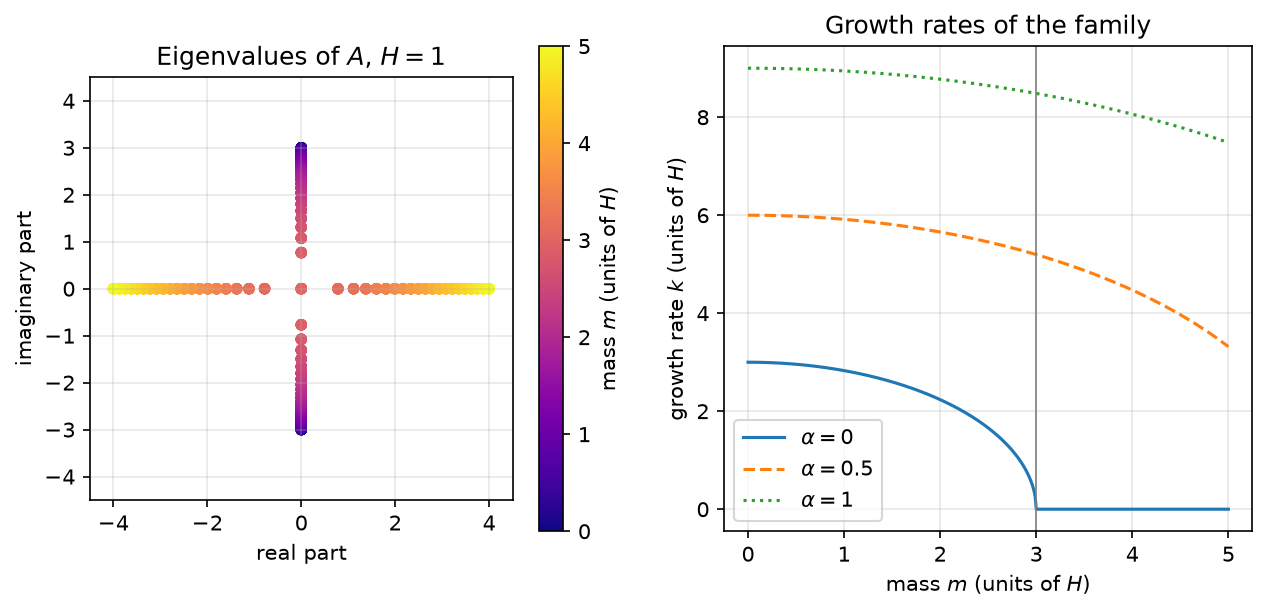

Figure 08d.4 saved as Revision/textbook/figures/08d_4_patch_end_modes.png


In [9]:
A_number = sp.lambdify((m, H), A, "numpy")
mass_path = np.linspace(0.0, 5.0, 51)
points = np.concatenate([np.linalg.eigvals(np.array(A_number(mv, 1.0), dtype=complex))
                         for mv in mass_path])
largest_growth = max(abs(points.imag))
report("largest |imaginary part| on the path (reached at m = 0)",
       f"{largest_growth:.9f}")
check(abs(largest_growth - 3.0) < 1e-9, "at m = 0 the growth rate is 3H")
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.2))
dots = left.scatter(points.real, points.imag, c=np.repeat(mass_path, 16),
                    cmap="plasma", s=20)
fig.colorbar(dots, ax=left, label="mass $m$ (units of $H$)")
left.set_aspect("equal")
left.set_xlim(-4.5, 4.5)
left.set_ylim(-4.5, 4.5)
left.set_xlabel("real part")
left.set_ylabel("imaginary part")
left.set_title("Eigenvalues of $A$, $H = 1$")
mass_fine = np.linspace(0.0, 5.0, 501)  # a finer grid for the smooth curves
for a_value, style in ((0.0, "-"), (0.5, "--"), (1.0, ":")):
    rate = np.sqrt(np.maximum(9 * (2 * a_value + 1) ** 2 - mass_fine**2, 0.0))
    right.plot(mass_fine, rate, style, label=f"$\\alpha = {a_value:g}$")
right.axvline(3.0, color="gray", linewidth=0.8)
right.set_xlabel("mass $m$ (units of $H$)")
right.set_ylabel("growth rate $k$ (units of $H$)")
right.set_title("Growth rates of the family")
right.legend();
save_figure(fig, "patch_end_modes",
            "Left: the eigenvalues $\\pm\\sqrt{m^2 - 9H^2}$ of the matrix $A = "
            "-im\\gamma^{(4)} + 3iH\\gamma^{(4)}\\gamma^{(8)}$, which acts on the "
            "$x_8$-independent fields of the good sector, in the complex plane, "
            "coloured by the mass $m$ from 0 to $5H$ ($H = 1$). For $m < 3H$ they "
            "lie on the imaginary axis (the mode $e^{-iEx_4}$ grows, at most like "
            "$e^{3Hx_4}$ at $m = 0$); at $m = 3H$ they meet at 0; for $m > 3H$ they "
            "are real. Right: the growth rate $k = \\sqrt{9H^2(2\\alpha + 1)^2 - "
            "m^2}$ of the members $\\alpha = 0, 0.5, 1$ of the exact family against "
            "$m$; members with larger $\\alpha$ still grow when $m > 3H$ (gray "
            "line).")

## 10. The boundary term at the patch end

For fields of $x_4$ and $x_8$ the mode operator is $h = -im\gamma^{(4)} +
i\gamma^{(4)}\gamma^{(8)}(\tan z\,\partial_8 + 3H)$. With $M_8 = i\gamma^{(4)}
\gamma^{(8)}$ the record proves, for all columns $u(x_8)$, $v(x_8)$,
$$\cos z\,\big[u^\dagger(hv) - (hu)^\dagger v\big] = \partial_8\big(\sin z\,
u^\dagger M_8 v\big).$$
It follows from three matrix facts: $\cos z\cdot(i\tan z\,\gamma^{(4)}\gamma^{(8)})
= \sin z\,M_8$ (the coefficient of $\partial_8$); $\cos z\,(A - A^\dagger) =
(\partial_8\sin z)\,M_8$ for the algebraic part $A$; and the coefficient of
$\partial_8$ is anti-Hermitian. The next cell checks the three facts, the identity
itself for two explicit columns of polynomials with complex coefficients, and the
value at the patch end: for $u$ with $\gamma^{(4)}\gamma^{(8)}u = u$,
$u^\dagger M_8u = i\,u^\dagger u \neq 0$. So $h$ is symmetric for the norm
$\int\cos z\,u^\dagger v\,dx_8$ only up to $[\sin z\,u^\dagger M_8v]$, which
vanishes at the tip ($\sin z \to 0$) but not at $z = \pi/2$ ($\sin z = 1$).

In [10]:
M8 = sp.I * G[3] * G[7]
d8_coefficient = sp.I * sp.tan(z) * G[3] * G[7]  # the matrix in front of d8 in h
fact_1 = all(is_zero(v) for v in sp.cos(z) * d8_coefficient - sp.sin(z) * M8)
fact_2 = all(is_zero(v) for v in sp.cos(z) * (A - A.H) - sp.diff(sp.sin(z), x[7]) * M8)
fact_3 = (d8_coefficient + d8_coefficient.H).applyfunc(sp.simplify) == sp.zeros(16, 16)
X8 = x[7]
u_col = sp.Matrix([(A_ + 1) + sp.I * (2 * A_ - 3) * X8 + (A_ - 5) * X8**2 / 3
                   for A_ in range(16)])  # a column of polynomials in x8
v_col = sp.Matrix([(3 - A_) * X8 + sp.I * (A_ + 2) + sp.I * A_ * X8**3 / 7
                   for A_ in range(16)])


def h_of(column):
    """The mode operator h applied to a column of functions of x8 (U = 0)."""
    return -sp.I * m * G[3] * column + sp.I * G[3] * G[7] * (
        sp.tan(z) * sp.diff(column, X8) + 3 * H * column)


left_side = sp.cos(z) * ((u_col.H * h_of(v_col))[0] - (h_of(u_col).H * v_col)[0])
right_side = sp.diff(sp.sin(z) * (u_col.H * M8 * v_col)[0], X8)
u0 = (G[3] * G[7] - sp.eye(16)).nullspace()[0]  # gamma^(4) gamma^(8) u0 = u0
flux = sp.simplify((u0.H * M8 * u0)[0])
size_u0 = (u0.H * u0)[0]
report("u0^dagger M8 u0 and u0^dagger u0", f"{flux}, {size_u0}")
# The record states the same identity and the same flux (sympy writes i as I):
check_record(fact_1 and fact_2 and fact_3 and is_zero(left_side - right_side)
             and flux == 2 * sp.I and size_u0 == 2,
             "cos z (u^dagger h v - (h u)^dagger v) = d8(sin z u^dagger M8 v); at "
             "z = pi/2 the flux u0^dagger M8 u0 = 2 i is not zero",
             SCOPE, "good_sector_hermiticity_up_to_the_brane_flux",
             "cos z [u^dagger (h v) - (h u)^dagger v] = d_x8(sin z u^dagger M8 v)",
             f"u^dagger M8 u = {sp.sstr(flux)} (|u|^2 = {sp.sstr(size_u0)})")

RESULT u0^dagger M8 u0 and u0^dagger u0 = 2*I, 2
PASS cos z (u^dagger h v - (h u)^dagger v) = d8(sin z u^dagger M8 v); at z = pi/2 the
    flux u0^dagger M8 u0 = 2 i is not zero
     reproduces Revision/theory/reports/python-scope.json, check
    good_sector_hermiticity_up_to_the_brane_flux


## 11. A growing mode is fed through the patch end

Integrate the identity of section 10 over the hidden direction. For a solution of
$i\,\partial_4\Psi = h\Psi$ the norm $N(x_4) = \int_0^{\pi/(12H)}\cos z\,
\Psi^\dagger\Psi\,dx_8$ changes, line by line, as
$\frac{dN}{dx_4} = \int\cos z\,\big[(-ih\Psi)^\dagger\Psi + \Psi^\dagger(-ih\Psi)
\big]dx_8 = -i\int\cos z\,\big[\Psi^\dagger h\Psi - (h\Psi)^\dagger\Psi\big]dx_8
= -i\big[\sin z\,\Psi^\dagger M_8\Psi\big]_{\rm tip}^{\rm end} =
\Psi^\dagger\gamma^{(4)}\gamma^{(8)}\Psi\big|_{z = \pi/2}$:
the norm changes ONLY through the patch end. The next cell follows the
$x_8$-independent mode $\Psi = e^{-iAx_4}\chi_0$ with $m = H = 1$ (so
$N = \Psi^\dagger\Psi/(6H)$) from a fixed random column $\chi_0$, computes
$dN/dx_4 = 2\,\mathrm{Re}\big(\Psi^\dagger(-iA\Psi)\big)/(6H)$ and the flux
$\Psi^\dagger\gamma^{(4)}\gamma^{(8)}\Psi$, checks that they agree, and draws them.
Interpretation (labelled): the growth is fed through the patch end; a boundary
condition at $z = \pi/2$ that stops this flux would change the spectrum, and which
condition is physical is a question this notebook does not decide.

PASS dN/dx4 equals the flux through the patch end at every x4
RESULT N(1.5) / N(0) = 2.094786e+03
PASS the norm grows by more than a factor 100


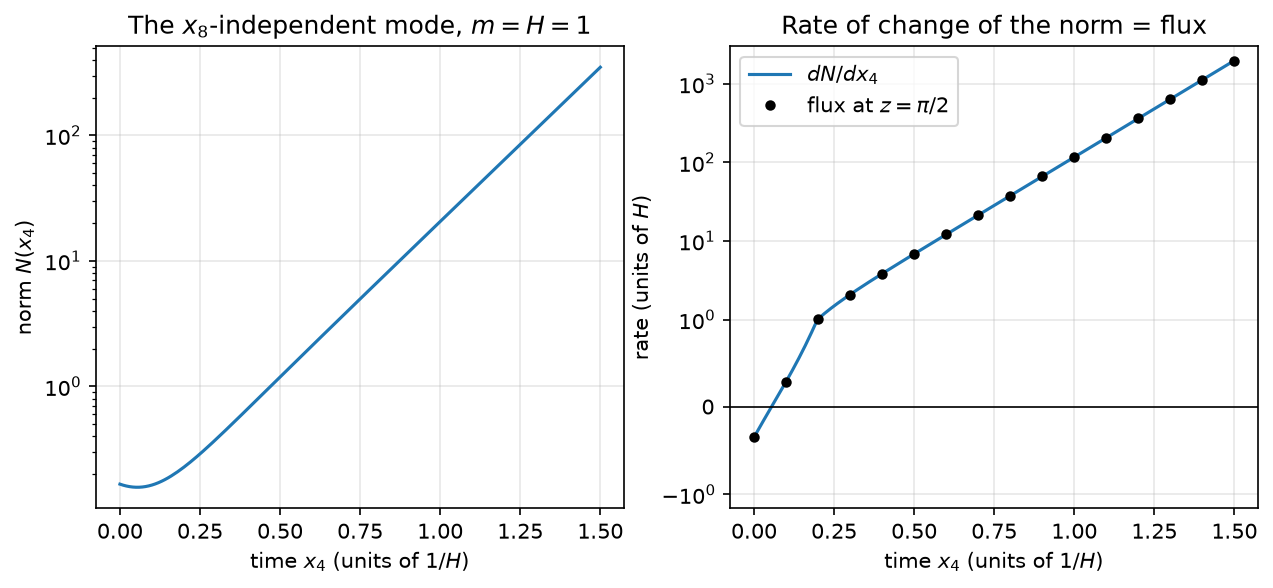

Figure 08d.5 saved as Revision/textbook/figures/08d_5_norm_and_flux.png


In [11]:
A_num = np.array(A_number(1.0, 1.0), dtype=complex)  # m = H = 1
g4g8 = np.array(G[3] * G[7], dtype=float)  # real symmetric
rng = np.random.default_rng(12345)  # fixed seed: the same column in every run
chi_start = rng.normal(size=16) + 1j * rng.normal(size=16)
chi_start = chi_start / np.linalg.norm(chi_start)
omega = np.sqrt(complex(1.0 - 9.0))  # A^2 = (m^2 - 9 H^2) = -8: omega = 2 sqrt(2) i
times = np.linspace(0.0, 1.5, 151)
norms, slopes, fluxes = [], [], []
for x4 in times:
    state = np.cos(omega * x4) * chi_start \
        - 1j * np.sin(omega * x4) / omega * (A_num @ chi_start)  # e^(-i A x4) chi
    norms.append(np.vdot(state, state).real / 6.0)  # N = Psi^dagger Psi / (6 H)
    slopes.append(2 * np.vdot(state, -1j * (A_num @ state)).real / 6.0)  # dN/dx4
    fluxes.append(np.vdot(state, g4g8 @ state).real)  # flux at z = pi/2
norms, slopes, fluxes = map(np.array, (norms, slopes, fluxes))
agreement = np.max(np.abs(slopes - fluxes) / np.maximum(np.abs(fluxes), 1.0))
check(agreement < 1e-12, "dN/dx4 equals the flux through the patch end at every x4")
report("N(1.5) / N(0)", f"{norms[-1] / norms[0]:.6e}")
check(norms[-1] / norms[0] > 100.0, "the norm grows by more than a factor 100")

fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
left.semilogy(times, norms)
left.set_xlabel("time $x_4$ (units of $1/H$)")
left.set_ylabel("norm $N(x_4)$")
left.set_title("The $x_8$-independent mode, $m = H = 1$")
right.plot(times, slopes, label="$dN/dx_4$")
right.plot(times[::10], fluxes[::10], "o", color="black", markersize=4,
           label="flux at $z = \\pi/2$")
right.axhline(0.0, color="black", linewidth=0.8)
right.set_yscale("symlog", linthresh=1.0)  # linear between -1 and 1, log outside
right.set_ylim(-1.5, 3.0e3)
right.set_xlabel("time $x_4$ (units of $1/H$)")
right.set_ylabel("rate (units of $H$)")
right.set_title("Rate of change of the norm = flux")
right.legend();
save_figure(fig, "norm_and_flux",
            "An $x_8$-independent mode of the good sector, $\\Psi = e^{-iAx_4}"
            "\\chi_0$ with $m = H = 1$ and a fixed random start $\\chi_0$, against "
            "the time $x_4$ in units of $1/H$. Left, on a logarithmic axis: its "
            "norm $N = \\int\\cos z\\,\\Psi^\\dagger\\Psi\\,dx_8$, which first dips "
            "and then grows like $e^{4\\sqrt2\\,x_4}$. Right, on an axis that is "
            "linear between $-1$ and $1$ and logarithmic outside: the rate of "
            "change $dN/dx_4$ (line) and the flux $\\Psi^\\dagger\\gamma^{(4)}"
            "\\gamma^{(8)}\\Psi$ through the patch end $z = \\pi/2$ (dots). They "
            "coincide at every time, also in the short first phase in which the "
            "flux is negative and the norm decreases: the norm changes only "
            "through the patch end, where the Revision record imposes no boundary "
            "condition.")

## 12. The last check

The last cell checks that the five figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [12]:
for name in ("08d_1_rescaling_factors.png", "08d_2_family_k_squared.png",
             "08d_3_growing_finite_norm.png", "08d_4_patch_end_modes.png",
             "08d_5_norm_and_flux.png"):
    check(output_file(f"{FIGURE_FOLDER}/{name}").is_file(),
          f"the figure file {name} exists")
all_checks_passed()

PASS the figure file 08d_1_rescaling_factors.png exists
PASS the figure file 08d_2_family_k_squared.png exists
PASS the figure file 08d_3_growing_finite_norm.png exists
PASS the figure file 08d_4_patch_end_modes.png exists
PASS the figure file 08d_5_norm_and_flux.png exists
ALL 23 CHECKS PASSED (notebook 08d)


## 13. What this notebook showed

- The spin connection of the record makes the gammas covariantly constant, and
  $\gamma^\mu\Omega_\mu = 3H\gamma^{(8)}$ in the diagonal frame (PROVED).
- The rescaling $\Psi = \sin^{-1/2}z\,\chi$ removes this term exactly: $\gamma^\mu
  D_\mu\Psi = \sin^{-1/2}z\,\gamma^\mu\partial_\mu\chi$ for every $\chi$, so for
  $U = 0$ the equation for $\chi$ has no spin-connection term, and for $U =
  \frac{\lambda}{2}S^2$ the term reappears as the $x_8$-dependent coupling
  $\lambda S[\chi]/\sin z$ (PROVED). The weight moves into the measure: the norm of
  $\Psi$ is $\int\chi^\dagger\chi\,dy$. Together with the frame dependence of
  the term, this is the exact scope of the statement "the field equation contains
  $3H\gamma^{(8)}$": it belongs to one frame AND one choice of field variables.
- The exact family $\sin^\alpha z\,e^{Mx_4}\chi_0$ solves the field equation for
  every $a_4$ (PROVED); its member $\alpha = -\frac12$ contains no $H$. Members with
  $3H|2\alpha + 1| > m$ grow; members with $\alpha > -\frac12$ have a finite norm at
  the tip; for every mass some member does both (PROVED here; the record states the
  case $\alpha = 0$, $m < 3H$).
- The $x_8$-independent modes of the good sector grow for $m < 3H$ (at $m = H = 1$
  with rate $2\sqrt2$) and have a finite norm (PROVED; Revision check
  `good_sector_x8_independent_modes_without_boundary_condition`).
- The mode operator is symmetric only up to the boundary term $[\sin z\,u^\dagger
  M_8v]$, which does not vanish at the patch end $z = \pi/2$ (PROVED), and the norm
  of the growing mode changes exactly by the flux through the patch end (COMPUTED,
  to rounding). Without a boundary condition at $z = \pi/2$ the initial-value
  problem of the good sector therefore has growing solutions; which boundary
  condition is physical is OPEN here (the Kohn-Sham record ASSUMES a $Z_2$ brane).